## What counts as a real light echo (written before looking at the data)
A feature is a real echo only if ALL of these are true:
1. It appears on several different nights in the same season.
2. It appears in both the g and r filters.
3. It does NOT appear in the 2018–2020 (pre-eruption) images processed the same way.
4. It moves outward from the nova from one season to the next.
Anything that fails a check is called a "candidate", not an echo.


In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:00


In [ ]:
from astroquery.mast import Observations
from astropy.time import Time

obs = Observations.query_criteria(objectname="V838 Mon", radius="0.02 deg",
                                  obs_collection="HST", instrument_name="ACS/WFC",
                                  dataproduct_type="image")
obs["date"] = Time(obs["t_min"], format="mjd").iso
print(len(obs), "observations found")

206 observations found


In [ ]:
obs.sort("t_min")
obs["obs_id", "date", "filters", "t_exptime"].pprint(max_lines=60)

                      obs_id                       ...  t_exptime  
-------------------------------------------------- ... ------------
  hst_skycell-p1169x07y20_acs_wfc_f435w-pol0uv_all ...       1012.0
           hst_9587_01_acs_wfc_f435w-pol0uv_j8gg01 ...        506.0
  hst_skycell-p1259x19y03_acs_wfc_f435w-pol0uv_all ...       1012.0
                  hst_9587_01_acs_wfc_total_j8gg01 ...       1518.0
                                         j8gg01010 ...        506.0
 hst_skycell-p1169x07y20_acs_wfc_f435w-pol60uv_all ...       1012.0
          hst_9587_01_acs_wfc_f435w-pol60uv_j8gg01 ...        506.0
 hst_skycell-p1259x19y03_acs_wfc_f435w-pol60uv_all ...       1012.0
                                         j8gg01020 ...        506.0
                                         j8gg01030 ...        506.0
hst_skycell-p1259x19y03_acs_wfc_f435w-pol120uv_all ...       1012.0
         hst_9587_01_acs_wfc_f435w-pol120uv_j8gg01 ...        506.0
hst_skycell-p1169x07y20_acs_wfc_f435w-pol120uv_a

In [ ]:
import numpy as np

keep = np.array([o.startswith("j") and "POL" not in f.upper()
                 for o, f in zip(obs["obs_id"], obs["filters"])])
good = obs[keep]
good["day"] = [d[:10] for d in good["date"]]
good["obs_id", "day", "filters", "t_exptime"].pprint_all()

  obs_id     day     filters t_exptime
--------- ---------- ------- ---------
j8gg01010 2002-04-30   F435W     506.0
j8gg01020 2002-04-30   F435W     506.0
j8gg01030 2002-04-30   F435W     506.0
j8gl03010 2002-05-20   F606W     362.0
j8gl03020 2002-05-20   F606W     362.0
j8gl03030 2002-05-20   F606W     362.0
j8gl03ilq 2002-05-20   F814W      30.0
j8gg02010 2002-05-20   F435W     506.0
j8gg02020 2002-05-20   F435W     506.0
j8gg02030 2002-05-21   F435W     506.0
j8jy04010 2002-09-02   F606W     960.0
j8jy04020 2002-09-02   F606W     960.0
j8jy04030 2002-09-02   F606W     960.0
j8jy04040 2002-09-02   F435W    1160.0
j8jy04060 2002-09-02   F814W     200.0
j8jy04050 2002-09-02   F435W    1720.0
j8jy05040 2002-10-28   F814W     360.0
j8jy05010 2002-10-28   F435W    2120.0
j8jy05020 2002-10-28   F435W    1700.0
j8jy05050 2002-10-28   F606W     700.0
j8jy05030 2002-10-28   F435W    2060.0
j8jy06010 2002-12-17   F606W     910.0
j8jy06020 2002-12-17   F606W     910.0
j8jy06030 2002-12-17   F6

In [ ]:
pick = good[(good["obs_id"] == "j8jy04050") | (good["obs_id"] == "j8jy06050")]
products = Observations.get_product_list(pick)
drz = Observations.filter_products(products, productSubGroupDescription="DRZ",
                                   extension="fits")
files = Observations.download_products(drz)
print(files["Local Path", "Status"])

                   Local Path                    Status 
----------------------------------------------- --------
./mastDownload/HST/j8jy06050/j8jy06051_drz.fits COMPLETE
./mastDownload/HST/j8jy04050/j8jy04051_drz.fits COMPLETE


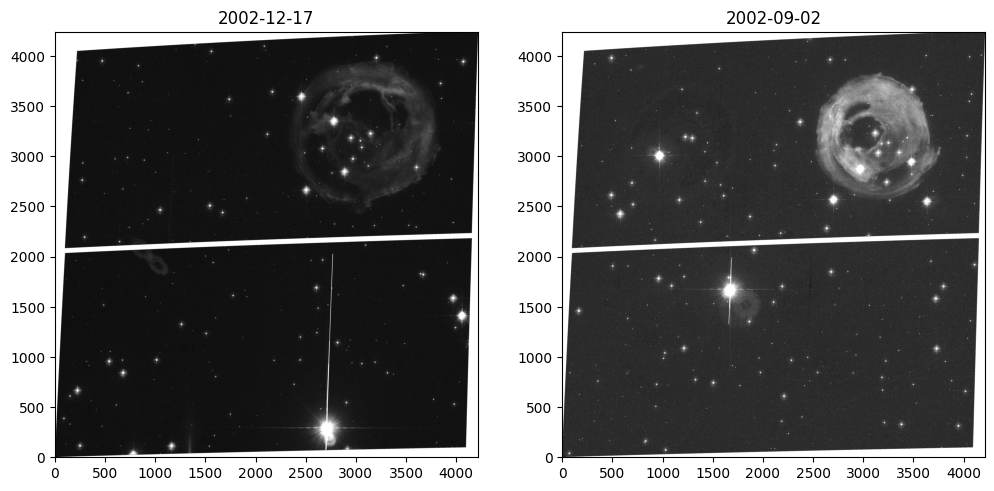

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, path in zip(axes, files["Local Path"]):
    data = fits.getdata(path, ext=1)
    ax.imshow(data, origin="lower", cmap="gray",
              norm=simple_norm(data, stretch="asinh", percent=99.5))
    ax.set_title(fits.getheader(path)["DATE-OBS"])
plt.show()

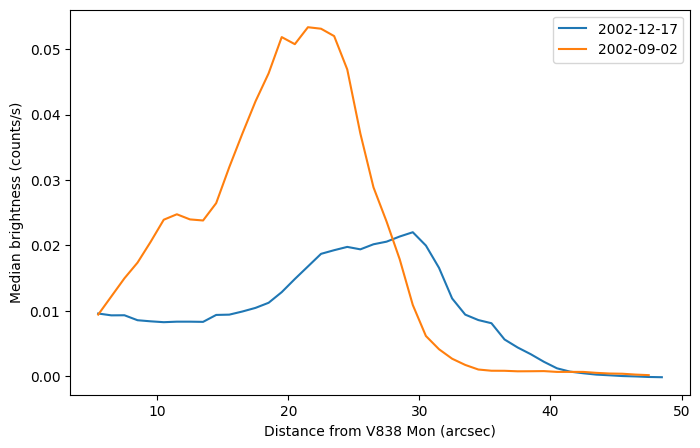

In [ ]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

star = SkyCoord.from_name("V838 Mon")
bins = np.arange(5, 80, 1.0)                     # rings from 5" to 80" from the star

plt.figure(figsize=(8, 5))
for path in files["Local Path"]:
    data = fits.getdata(path, ext=1)
    w = WCS(fits.getheader(path, ext=1))
    date = fits.getheader(path)["DATE-OBS"]
    x0, y0 = w.world_to_pixel(star)              # where the star is in this image
    yy, xx = np.indices(data.shape)
    r = np.hypot(xx - x0, yy - y0) * 0.05        # distance from the star, in arcsec
    ok = data != 0                               # skip the empty edges and chip gap
    prof = [np.median(data[ok & (r >= b) & (r < b + 1)]) for b in bins]
    plt.plot(bins + 0.5, prof, label=date)

plt.xlabel("Distance from V838 Mon (arcsec)")
plt.ylabel("Median brightness (counts/s)")
plt.legend()
plt.show()

In [ ]:
d_ly = 6100 * 3.2616          # distance to V838 Mon: 6.1 kpc, in light-years
flash = Time("2002-02-06")    # main outburst peak

for date, edge in [("2002-09-02", 27.0), ("2002-12-17", 32.9)]:
    t = (Time(date) - flash).to("yr").value     # years since the flash (= c*t in light-years)
    x = d_ly * edge / 206265                    # edge distance across the sky, in light-years
    z = x**2 / (2 * t) - t / 2                  # paraboloid: how far in front of the star
    print(f"{date}: t = {t:.2f} yr, x = {x:.2f} ly, dust is {z:.1f} ly in front of the star")

2002-09-02: t = 0.57 yr, x = 2.60 ly, dust is 5.7 ly in front of the star
2002-12-17: t = 0.86 yr, x = 3.17 ly, dust is 5.4 ly in front of the star


In [ ]:
from astropy.table import Table
from astropy.utils.data import conf
from collections import Counter

conf.remote_timeout = 300     # wait up to 5 minutes for IRSA (default is 10 seconds)

nova = SkyCoord.from_name("V1405 Cas")
url = ("https://irsa.ipac.caltech.edu/ibe/search/ztf/products/sci"
       f"?POS={nova.ra.deg},{nova.dec.deg}")
meta = Table.read(url, format="ipac")
meta["year"] = Time(meta["obsjd"], format="jd").decimalyear.astype(int)

print(len(meta), "ZTF images cover V1405 Cas")
print("Field/CCD/quadrant:", sorted({(int(f), int(c), int(q))
      for f, c, q in zip(meta["field"], meta["ccdid"], meta["qid"])}))
for (year, band), n in sorted(Counter(zip(meta["year"], meta["filtercode"])).items()):
    print(year, band, n)

1756 ZTF images cover V1405 Cas
Field/CCD/quadrant: [(832, 7, 2), (832, 7, 3)]
2018 zg 138
2018 zi 1
2018 zr 157
2019 zg 152
2019 zr 307
2020 zg 130
2020 zi 51
2020 zr 141
2021 zg 83
2021 zr 77
2022 zg 68
2022 zr 66
2023 zg 64
2023 zi 1
2023 zr 64
2024 zg 66
2024 zi 1
2024 zr 75
2025 zg 44
2025 zr 51
2026 zg 11
2026 zr 8


In [ ]:
# Setup: run this first every time Colab restarts
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from astropy.time import Time
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.utils.data import conf
from collections import Counter

conf.remote_timeout = 300                 # give IRSA up to 5 minutes to answer
nova = SkyCoord.from_name("V1405 Cas")

url = ("https://irsa.ipac.caltech.edu/ibe/search/ztf/products/sci"
       f"?POS={nova.ra.deg},{nova.dec.deg}")
meta = Table.read(url, format="ipac")
meta["year"] = Time(meta["obsjd"], format="jd").decimalyear.astype(int)
print(len(meta), "ZTF images found")      # should say 1756

1756 ZTF images found


In [ ]:
ref_url = ("https://irsa.ipac.caltech.edu/ibe/search/ztf/products/ref"
           f"?POS={nova.ra.deg},{nova.dec.deg}")
refs = Table.read(ref_url, format="ipac")
cols = [c for c in ["field", "ccdid", "qid", "filtercode",
                    "startobsdate", "endobsdate", "nframes"] if c in refs.colnames]
refs[cols].pprint_all()

field ccdid qid filtercode        startobsdate               endobsdate         nframes
----- ----- --- ---------- ------------------------- -------------------------- -------
  832     7   3         zg 2018-05-08 11:39:34.92+00 2018-06-18 10:22:55.348+00      15
  832     7   2         zg 2018-05-08 11:39:34.92+00 2018-06-18 10:22:55.348+00      15
  832     7   2         zr  2018-05-08 10:49:13.6+00 2018-06-16 09:47:20.262+00      15
  832     7   3         zr  2018-05-08 10:49:13.6+00 2018-06-19 11:18:27.289+00      15


First address tried: https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2023/1106/116725/ztf_20231106116725_000832_zr_c07_o_q3_scimrefdiffimg.fits.fz
Not found (error 404 ), trying the next image


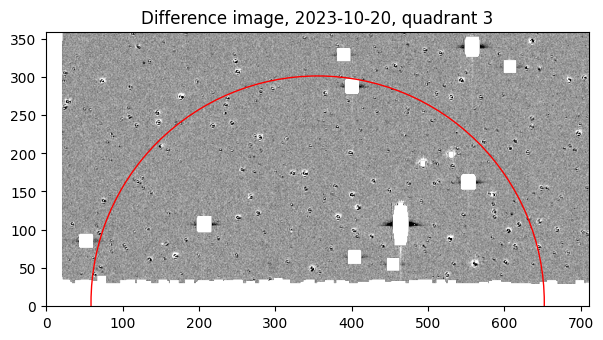

In [ ]:
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.utils.data import download_file
from urllib.error import HTTPError

def ztf_url(row, suffix):
    ffd = str(int(row["filefracday"]))
    return (f"https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/"
            f"{ffd[:4]}/{ffd[4:8]}/{ffd[8:]}/ztf_{ffd}_{int(row['field']):06d}_"
            f"{row['filtercode']}_c{int(row['ccdid']):02d}_{row['imgtypecode']}_"
            f"q{int(row['qid'])}_{suffix}")

test = meta[(meta["year"] == 2023) & (meta["filtercode"] == "zr") & (meta["seeing"] > 0)]
test.sort("seeing")                                  # sharpest first
print("First address tried:", ztf_url(test[0], "scimrefdiffimg.fits.fz"))

path = None
for row in test[:10]:                                # try up to 10, skip missing files
    try:
        path = download_file(ztf_url(row, "scimrefdiffimg.fits.fz"), cache=True)
        break
    except HTTPError as err:
        print("Not found (error", err.code, "), trying the next image")

if path is None:
    print("None of the 10 images had a difference file.")
else:
    with fits.open(path) as hdul:
        cut = Cutout2D(hdul[1].data, nova, size=12 * u.arcmin, wcs=WCS(hdul[1].header))
    xn, yn = cut.wcs.world_to_pixel(nova)
    plt.figure(figsize=(7, 7))
    plt.imshow(cut.data, origin="lower", cmap="gray",
               norm=simple_norm(cut.data, stretch="linear", percent=99))
    plt.gca().add_patch(plt.Circle((xn, yn), 300 / 1.01, fill=False, color="red"))
    plt.title(f"Difference image, {Time(row['obsjd'], format='jd').iso[:10]}, quadrant {row['qid']}")
    plt.show()

In [ ]:
!pip install -q reproject

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.3/405.3 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.6 MB/s eta 0:00:00


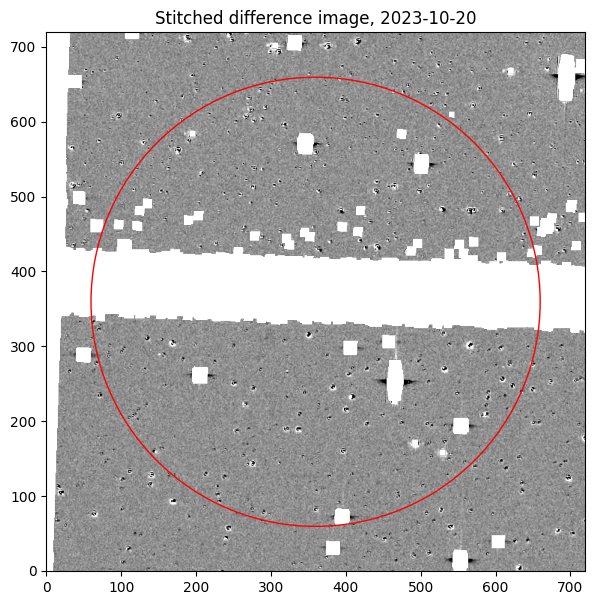

In [ ]:
from reproject import reproject_interp
from urllib.error import HTTPError

def ztf_url(row, suffix, qid=None):
    ffd = str(int(row["filefracday"]))
    q = int(row["qid"]) if qid is None else qid
    return (f"https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/"
            f"{ffd[:4]}/{ffd[4:8]}/{ffd[8:]}/ztf_{ffd}_{int(row['field']):06d}_"
            f"{row['filtercode']}_c{int(row['ccdid']):02d}_{row['imgtypecode']}_"
            f"q{q}_{suffix}")

# a 12' x 12' grid centred on the nova, 1 arcsec per pixel, north up
grid = WCS(naxis=2)
grid.wcs.ctype = ["RA---TAN", "DEC--TAN"]
grid.wcs.crval = [nova.ra.deg, nova.dec.deg]
grid.wcs.crpix = [360.5, 360.5]
grid.wcs.cdelt = [-1 / 3600, 1 / 3600]
shape = (720, 720)

def stitched_diff(row):
    """Put quadrants 2 and 3 of one exposure onto the grid and merge them."""
    merged = np.full(shape, np.nan)
    for q in (2, 3):
        try:
            path = download_file(ztf_url(row, "scimrefdiffimg.fits.fz", qid=q), cache=True)
        except HTTPError:
            continue                      # skip a missing quadrant
        with fits.open(path) as hdul:
            arr, _ = reproject_interp((hdul[1].data, WCS(hdul[1].header)), grid, shape_out=shape)
        merged = np.where(np.isnan(merged), arr, merged)
    return merged

img = stitched_diff(row)
plt.figure(figsize=(7, 7))
plt.imshow(img, origin="lower", cmap="gray", norm=simple_norm(img, stretch="linear", percent=99))
plt.gca().add_patch(plt.Circle((359.5, 359.5), 300, fill=False, color="red"))
plt.title(f"Stitched difference image, {Time(row['obsjd'], format='jd').iso[:10]}")
plt.show()

In [ ]:
import os
from google.colab import drive

drive.mount("/content/drive")
outdir = "/content/drive/MyDrive/v1405cas_echo/stitched"
os.makedirs(outdir, exist_ok=True)

def stitched_diff(row):
    """Download quadrants 2 and 3 of one exposure, put them on the grid, merge them."""
    merged = np.full(shape, np.nan, dtype=np.float32)
    for q in (2, 3):
        try:
            path = download_file(ztf_url(row, "scimrefdiffimg.fits.fz", qid=q), cache=False)
        except HTTPError:
            continue
        with fits.open(path) as hdul:
            arr, _ = reproject_interp((hdul[1].data, WCS(hdul[1].header)), grid, shape_out=shape)
        os.remove(path)                              # delete the big file, keep only the cutout
        merged = np.where(np.isnan(merged), arr, merged)
    return merged

season = meta[(meta["year"] == 2023) & (meta["filtercode"] == "zr")]
for i, row in enumerate(season):
    out = f"{outdir}/{int(row['filefracday'])}_{row['filtercode']}.fits"
    if os.path.exists(out):
        continue                                     # already done earlier
    img = stitched_diff(row)
    hdr = grid.to_header()
    hdr["OBSJD"] = float(row["obsjd"])
    fits.writeto(out, img, hdr, overwrite=True)
    print(f"{i + 1}/{len(season)} done")

Mounted at /content/drive
1/64 done
2/64 done
3/64 done
4/64 done
5/64 done
6/64 done
7/64 done
8/64 done
9/64 done
10/64 done
11/64 done
12/64 done
13/64 done
14/64 done
15/64 done
16/64 done
17/64 done
18/64 done
19/64 done
20/64 done
21/64 done
22/64 done
23/64 done
24/64 done
25/64 done
26/64 done
27/64 done
28/64 done
29/64 done
30/64 done
31/64 done
32/64 done
33/64 done
34/64 done
35/64 done
36/64 done
37/64 done
38/64 done
39/64 done
40/64 done
41/64 done
42/64 done
43/64 done
44/64 done
45/64 done
46/64 done
47/64 done
48/64 done
49/64 done
50/64 done
51/64 done
52/64 done
53/64 done
54/64 done
55/64 done
56/64 done
57/64 done
58/64 done
59/64 done
60/64 done
61/64 done
62/64 done
63/64 done
64/64 done


/tmp/ipykernel_635/1262391176.py:4: RuntimeWarning: All-NaN slice encountered
  stack = np.nanmedian([fits.getdata(f) for f in files], axis=0)


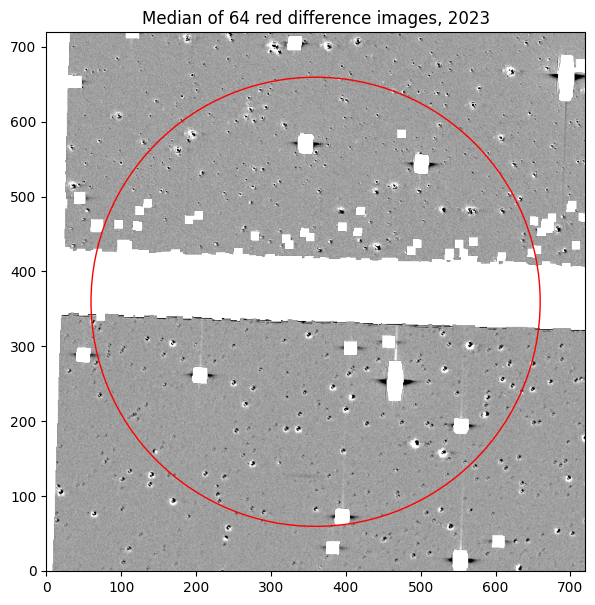

In [ ]:
import glob

files = sorted(glob.glob(f"{outdir}/2023*_zr.fits"))
stack = np.nanmedian([fits.getdata(f) for f in files], axis=0)

plt.figure(figsize=(7, 7))
plt.imshow(stack, origin="lower", cmap="gray", norm=simple_norm(stack, stretch="linear", percent=99))
plt.gca().add_patch(plt.Circle((359.5, 359.5), 300, fill=False, color="red"))
plt.title(f"Median of {len(files)} red difference images, 2023")
plt.show()

In [ ]:
def make_season(year, band, max_n=None):
    rows = meta[(meta["year"] == year) & (meta["filtercode"] == band) & (meta["seeing"] > 0)]
    rows.sort("seeing")
    if max_n:
        rows = rows[:max_n]
    for i, row in enumerate(rows):
        out = f"{outdir}/{int(row['filefracday'])}_{row['filtercode']}.fits"
        if os.path.exists(out):
            continue
        img = stitched_diff(row)
        hdr = grid.to_header()
        hdr["OBSJD"] = float(row["obsjd"])
        fits.writeto(out, img, hdr, overwrite=True)
        print(f"{year} {band}: {i + 1}/{len(rows)} done")

make_season(2020, "zr", max_n=64)

2020 zr: 1/64 done
2020 zr: 2/64 done
2020 zr: 3/64 done
2020 zr: 4/64 done
2020 zr: 5/64 done
2020 zr: 6/64 done
2020 zr: 7/64 done
2020 zr: 8/64 done
2020 zr: 9/64 done
2020 zr: 10/64 done
2020 zr: 11/64 done
2020 zr: 12/64 done
2020 zr: 13/64 done
2020 zr: 14/64 done
2020 zr: 15/64 done
2020 zr: 16/64 done
2020 zr: 17/64 done
2020 zr: 18/64 done
2020 zr: 19/64 done
2020 zr: 20/64 done
2020 zr: 21/64 done
2020 zr: 22/64 done
2020 zr: 23/64 done
2020 zr: 24/64 done
2020 zr: 25/64 done
2020 zr: 26/64 done
2020 zr: 27/64 done
2020 zr: 28/64 done
2020 zr: 29/64 done
2020 zr: 30/64 done
2020 zr: 31/64 done
2020 zr: 32/64 done
2020 zr: 33/64 done
2020 zr: 34/64 done
2020 zr: 35/64 done
2020 zr: 36/64 done
2020 zr: 37/64 done
2020 zr: 38/64 done
2020 zr: 39/64 done
2020 zr: 40/64 done
2020 zr: 41/64 done
2020 zr: 42/64 done
2020 zr: 43/64 done
2020 zr: 44/64 done
2020 zr: 45/64 done
2020 zr: 46/64 done
2020 zr: 47/64 done
2020 zr: 48/64 done
2020 zr: 49/64 done
2020 zr: 50/64 done
2020 zr: 

/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


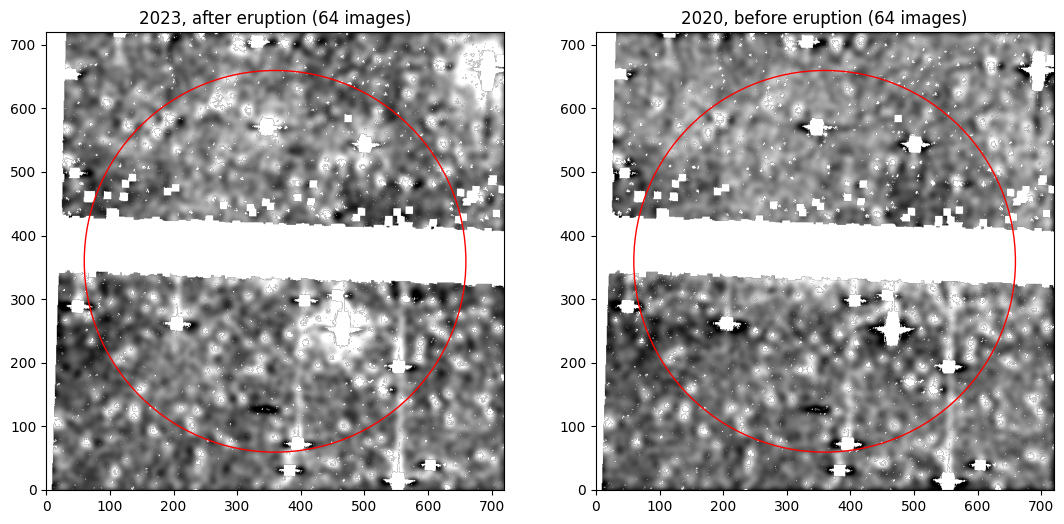

In [ ]:
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.stats import sigma_clipped_stats

def season_stack(year, band):
    files = sorted(glob.glob(f"{outdir}/{year}*_{band}.fits"))
    return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)

def smooth(stack):
    _, med, std = sigma_clipped_stats(stack)                      # background level and noise
    clean = np.where(np.abs(stack - med) > 3 * std, np.nan, stack)  # hide star leftovers
    return convolve(clean, Gaussian2DKernel(5), preserve_nan=True) - med

s23, n23 = season_stack(2023, "zr")
s20, n20 = season_stack(2020, "zr")
a, b = smooth(s23), smooth(s20)
lim = 3 * np.nanstd(b)                                            # same scale for both panels

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, im, title in zip(axes, [a, b], [f"2023, after eruption ({n23} images)",
                                        f"2020, before eruption ({n20} images)"]):
    ax.imshow(im, origin="lower", cmap="gray", vmin=-lim, vmax=lim)
    ax.add_patch(plt.Circle((359.5, 359.5), 300, fill=False, color="red"))
    ax.set_title(title)
plt.show()

In [ ]:
def make_season(year, band, max_n=None):
    rows = meta[(meta["year"] == year) & (meta["filtercode"] == band) & (meta["seeing"] > 0)]
    rows.sort("seeing")
    if max_n:
        rows = rows[:max_n]
    for row in rows:
        out = f"{outdir}/{int(row['filefracday'])}_{row['filtercode']}.fits"
        if os.path.exists(out):
            continue
        hdr = grid.to_header()
        hdr["OBSJD"] = float(row["obsjd"])
        fits.writeto(out, stitched_diff(row), hdr, overwrite=True)
    print(f"{year} {band}: finished ({len(rows)} images)")

for year in [2022, 2023, 2024, 2025]:
    for band in ["zg", "zr"]:
        make_season(year, band)
make_season(2020, "zg", max_n=64)        # green control

2022 zg: finished (68 images)
2022 zr: finished (66 images)
2023 zg: finished (64 images)
2023 zr: finished (64 images)
2024 zg: finished (66 images)
2024 zr: finished (75 images)
2025 zg: finished (44 images)
2025 zr: finished (51 images)
2020 zg: finished (64 images)


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountere

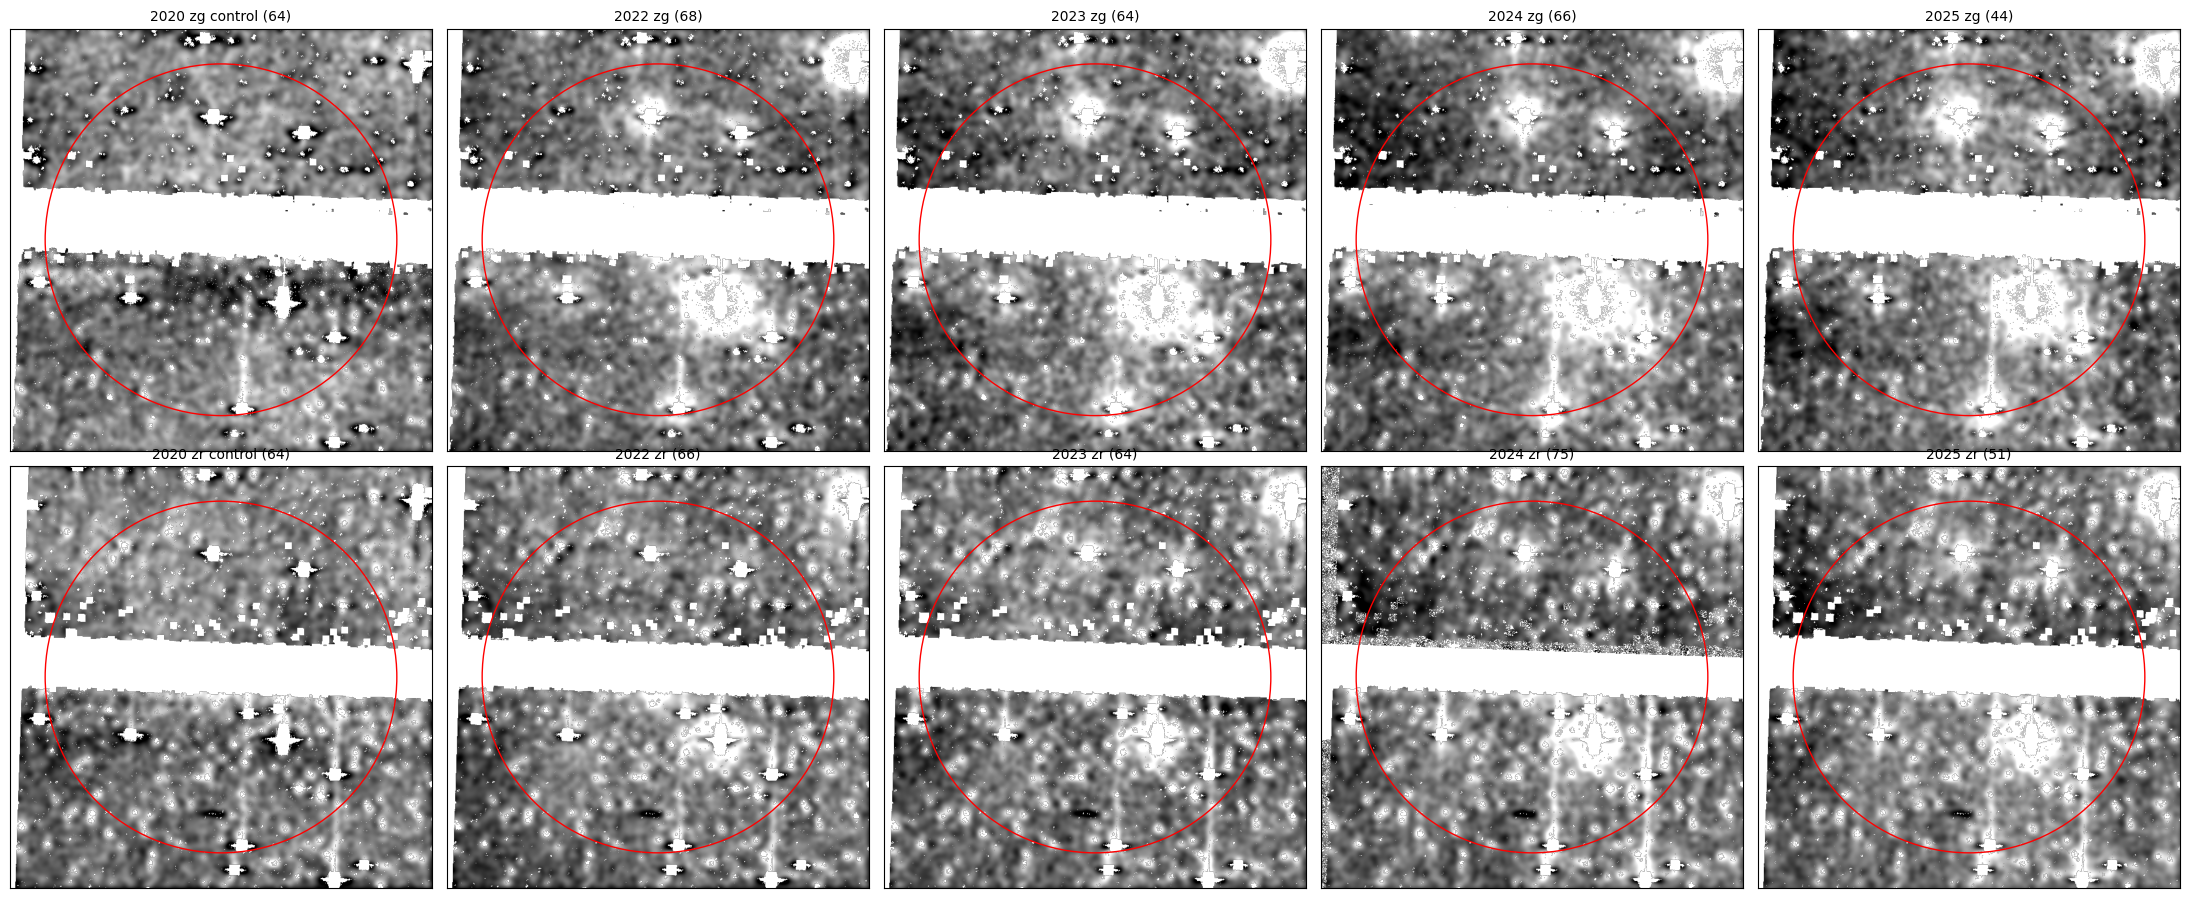

In [ ]:
years = [2022, 2023, 2024, 2025]
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for r, band in enumerate(["zg", "zr"]):
    ctrl, n = season_stack(2020, band)
    ctrl_s = smooth(ctrl)
    lim = 3 * np.nanstd(ctrl_s)
    panels = [(ctrl_s, f"2020 {band} control ({n})")]
    for y in years:
        s, n = season_stack(y, band)
        panels.append((smooth(s), f"{y} {band} ({n})"))
    for ax, (im, title) in zip(axes[r], panels):
        ax.imshow(im, origin="lower", cmap="gray", vmin=-lim, vmax=lim)
        ax.add_patch(plt.Circle((359.5, 359.5), 300, fill=False, color="red"))
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
make_season(2020, "zg")
make_season(2020, "zr")

2020 zg: finished (130 images)
2020 zr: finished (141 images)


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)
/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountere

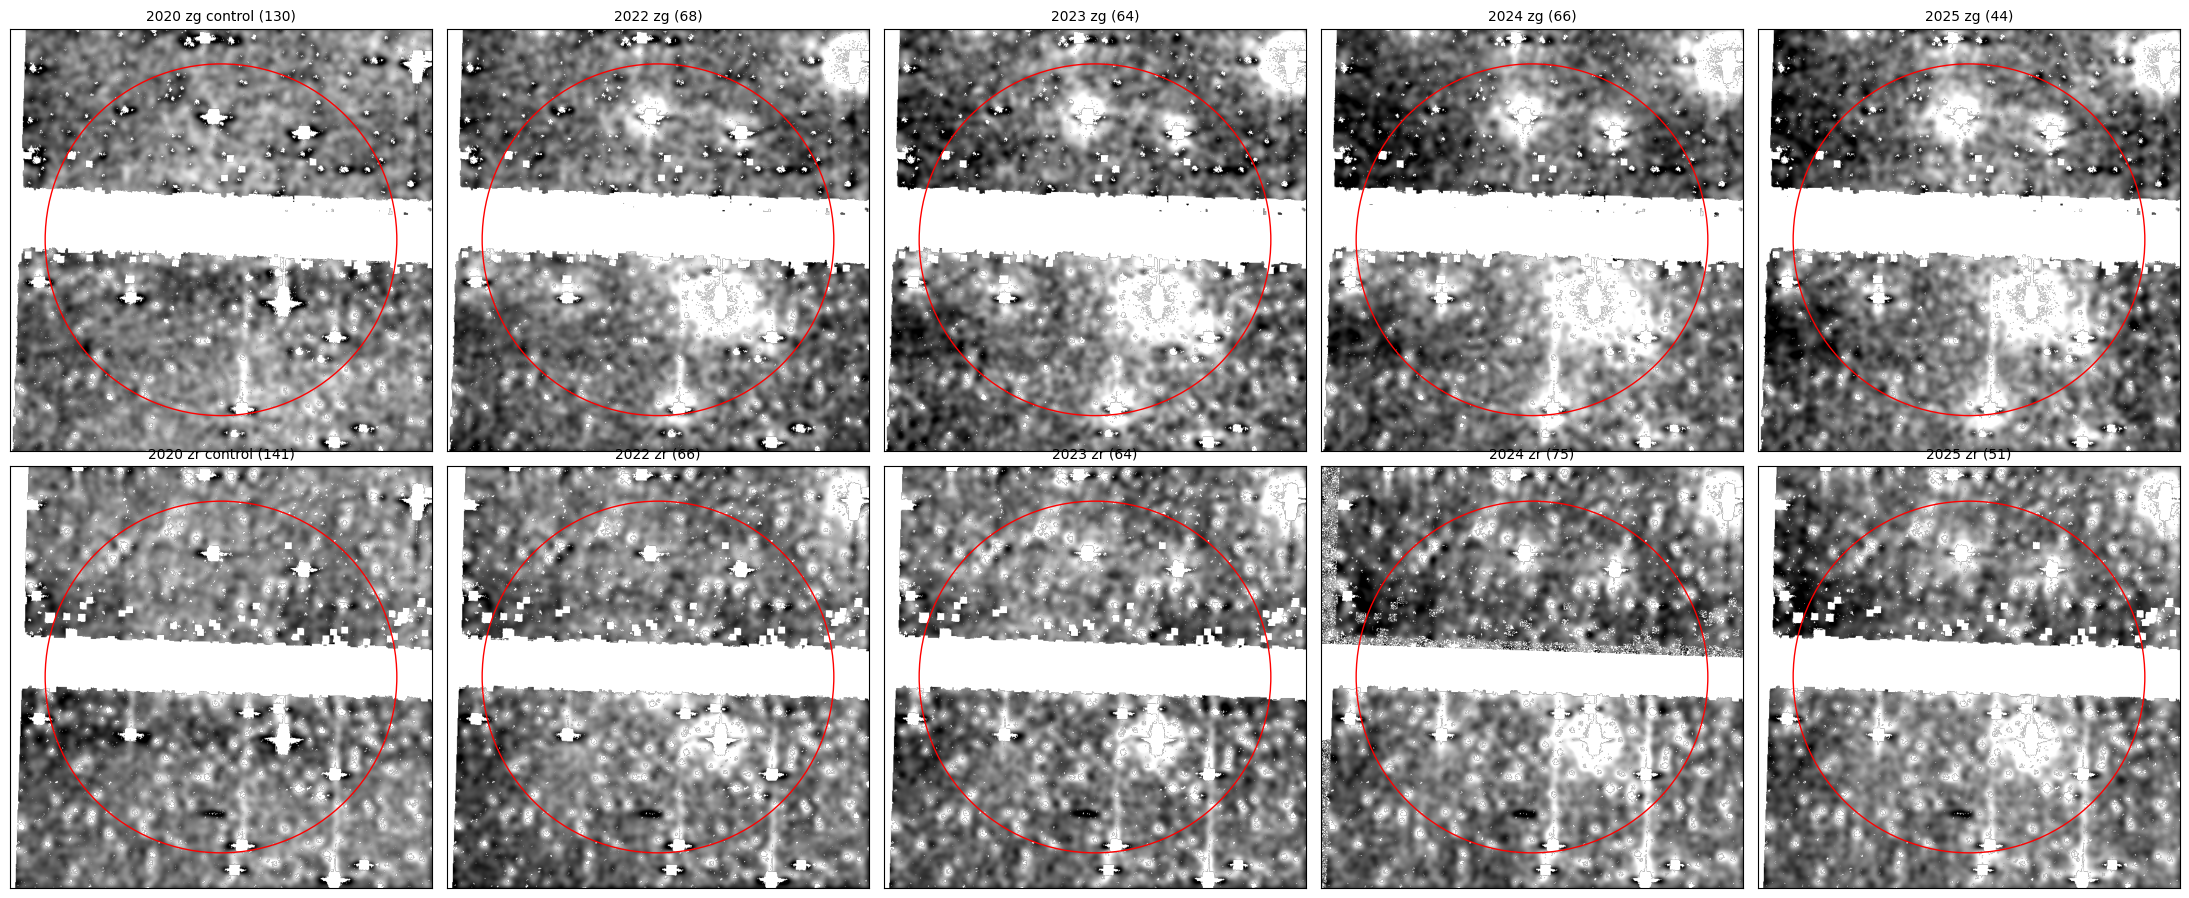

In [ ]:
years = [2022, 2023, 2024, 2025]
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for r, band in enumerate(["zg", "zr"]):
    ctrl, n = season_stack(2020, band)
    ctrl_s = smooth(ctrl)
    lim = 3 * np.nanstd(ctrl_s)
    panels = [(ctrl_s, f"2020 {band} control ({n})")]
    for y in years:
        s, n = season_stack(y, band)
        panels.append((smooth(s), f"{y} {band} ({n})"))
    for ax, (im, title) in zip(axes[r], panels):
        ax.imshow(im, origin="lower", cmap="gray", vmin=-lim, vmax=lim)
        ax.add_patch(plt.Circle((359.5, 359.5), 300, fill=False, color="red"))
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


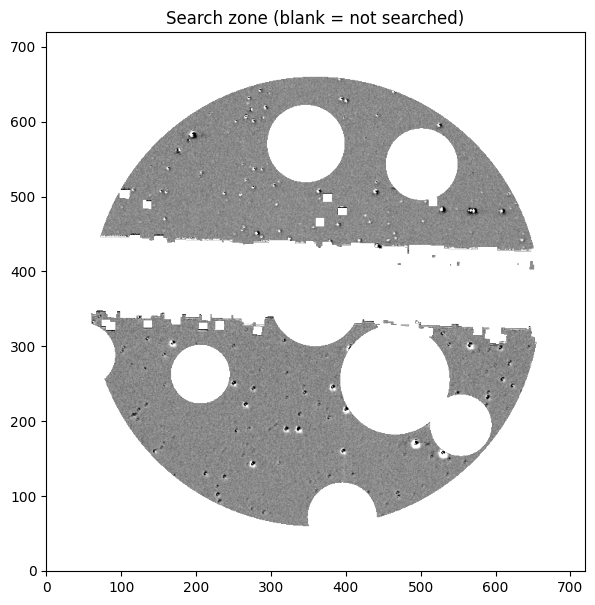

In [ ]:
from scipy import ndimage

# Bright stars show up as blank (NaN) blobs in the control stack.
ctrl, _ = season_stack(2020, "zg")
labels, n = ndimage.label(np.isnan(ctrl))
yy, xx = np.indices(shape)
star_mask = np.zeros(shape, bool)
for i in range(1, n + 1):
    ys, xs = np.nonzero(labels == i)
    on_edge = ys.min() == 0 or xs.min() == 0 or ys.max() == shape[0] - 1 or xs.max() == shape[1] - 1
    if 300 < len(ys) < 5000 and not on_edge:        # a big star, not the band or a border
        star_mask |= np.hypot(xx - xs.mean(), yy - ys.mean()) < 4 * np.sqrt(len(ys) / np.pi)

r = np.hypot(xx - 359.5, yy - 359.5)                # distance from the nova, in arcsec
zone = (r > 60) & (r < 300) & ~star_mask            # search zone: 1' to 5' from the nova

plt.figure(figsize=(7, 7))
plt.imshow(np.where(zone, ctrl, np.nan), origin="lower", cmap="gray",
           norm=simple_norm(ctrl, stretch="linear", percent=99))
plt.title("Search zone (blank = not searched)")
plt.show()

In [18]:
def get_zp(row):
    """Read the zero point (MAGZP) from the header of a tiny science-image cutout."""
    url = (ztf_url(row, "sciimg.fits")
           + f"?center={nova.ra.deg},{nova.dec.deg}&size=10pix&gzip=false")
    try:
        return fits.getheader(download_file(url, cache=True))["MAGZP"]
    except (HTTPError, KeyError):
        return np.nan

print("season  filter  images  zero point  5-sigma limit (mag/arcsec^2)")
for band in ["zg", "zr"]:
    for y in [2022, 2023, 2024, 2025]:
        rows = meta[(meta["year"] == y) & (meta["filtercode"] == band) & (meta["seeing"] > 0)]
        sample = rows[:: max(1, len(rows) // 10)][:10]       # ~10 images spread over the season
        zp = np.nanmedian([get_zp(row) for row in sample])
        s, n = season_stack(y, band)
        _, _, noise = sigma_clipped_stats(smooth(s)[zone])   # typical wobble in the search zone
        limit = zp - 2.5 * np.log10(5 * noise)               # each pixel is 1 square arcsec
        print(f"{y}    {band}      {n:4d}     {zp:.2f}       {limit:.1f}")

season  filter  images  zero point  5-sigma limit (mag/arcsec^2)


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


2022    zg        68     26.33       26.6


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


2023    zg        64     26.33       26.4


...

2023    zr        64     26.32       26.0


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


2024    zr        75     26.30       25.8


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


2025    zr        51     26.33       25.9


/tmp/ipykernel_635/3060906917.py:6: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian([fits.getdata(f) for f in files], axis=0), len(files)


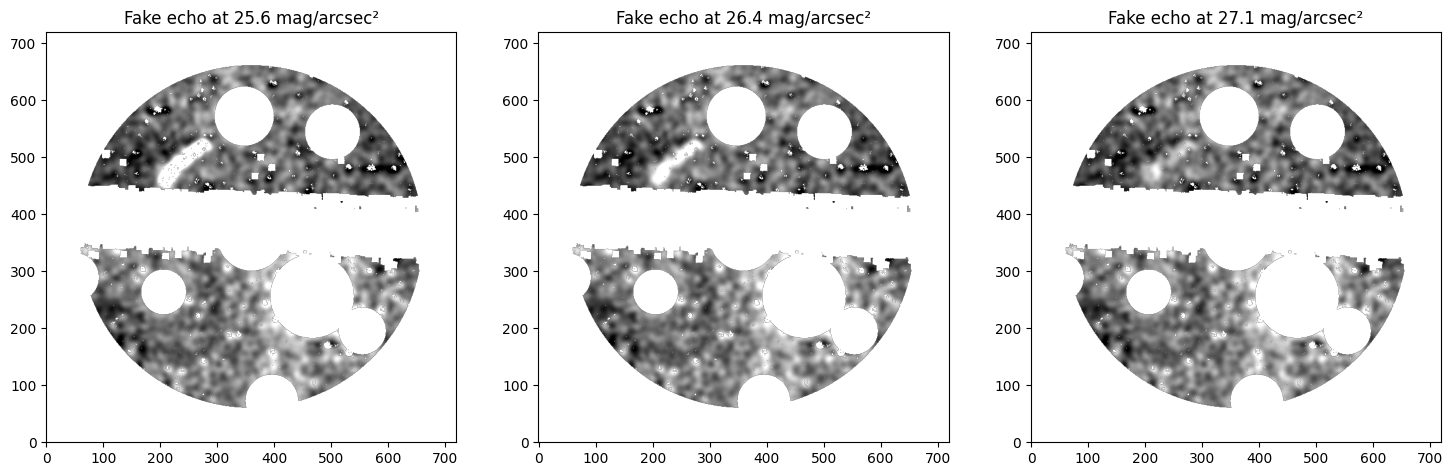

In [19]:
y, band, zp = 2023, "zg", 26.33
s, n = season_stack(y, band)
_, _, noise = sigma_clipped_stats(smooth(s)[zone])
limit = zp - 2.5 * np.log10(5 * noise)

az = np.degrees(np.arctan2(yy - 359.5, xx - 359.5)) % 360
arc = (np.abs(r - 180) < 10) & (az > 115) & (az < 150)    # 20"-wide arc, 3' from the nova

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sb in zip(axes, [limit - 0.75, limit, limit + 0.75]):
    fake = np.where(arc, 10 ** (-0.4 * (sb - zp)), 0.0)  # fake echo, in counts per pixel
    test_img = smooth(s + fake)
    ax.imshow(np.where(zone, test_img, np.nan), origin="lower", cmap="gray",
              vmin=-3 * noise, vmax=3 * noise)
    ax.set_title(f"Fake echo at {sb:.1f} mag/arcsec²")
plt.show()